## 1. Load the raw data

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DB_PATH = "traffic_data.db"

# Open a connection, pull both tables into pandas, then close the
# connection immediately — we don't need to keep it open once the data
# is loaded into memory.
conn = sqlite3.connect(DB_PATH)
traffic_raw = pd.read_sql_query("SELECT * FROM traffic_readings", conn)
weather = pd.read_sql_query("SELECT * FROM weather_readings", conn)
conn.close()

# Timestamps come out of SQLite as plain text; convert to real datetime
# objects so we can do date math (subtract, extract hour, sort, etc.)
traffic_raw["timestamp_utc"] = pd.to_datetime(traffic_raw["timestamp_utc"])
weather["timestamp_utc"] = pd.to_datetime(weather["timestamp_utc"])
traffic_raw = traffic_raw.sort_values(["segment_id", "timestamp_utc"]).reset_index(drop=True)

print(f"Total raw rows: {len(traffic_raw)}")
print(f"Weather rows: {len(weather)}")
traffic_raw.drop(columns=["raw_response"]).groupby("segment_id").agg(
    rows=("id", "count"),
    min_distance_m=("distance_m", "min"),
    max_distance_m=("distance_m", "max"),
    first_seen=("timestamp_utc", "min"),
    last_seen=("timestamp_utc", "max"),
)

Total raw rows: 846
Weather rows: 205


,rows,min_distance_m,max_distance_m,first_seen,last_seen
segment_id,,,,,
abay_ave,119,3263,4836,2026-07-21 13:15:35.027595+00:00,2026-08-06 01:27:32.780217+00:00
dostyk_left_bank,119,2010,2039,2026-07-21 13:15:35.027595+00:00,2026-08-06 01:27:32.780217+00:00
kabanbay_batyr,121,3888,16859,2026-07-21 13:15:35.027595+00:00,2026-08-06 01:27:32.780217+00:00
mangilik_el,83,11190,12488,2026-07-25 07:10:49.256876+00:00,2026-08-06 01:27:32.780217+00:00
respublika_ave,119,3705,4252,2026-07-21 13:15:35.027595+00:00,2026-08-06 01:27:32.780217+00:00
tauelsizdik_ave,83,7565,8646,2026-07-25 07:10:49.256876+00:00,2026-08-06 01:27:32.780217+00:00
turan_ave,83,5118,5473,2026-07-25 07:10:49.256876+00:00,2026-08-06 01:27:32.780217+00:00
turan_ave_n,119,2473,3828,2026-07-21 13:15:35.027595+00:00,2026-08-06 01:27:32.780217+00:00


In [2]:
def clean_segment_routes(df):
    cleaned_parts = []
    log_lines = []
    for seg_id, group in df.groupby("segment_id"):
        group = group.sort_values("timestamp_utc")
        dmin, dmax = group["distance_m"].min(), group["distance_m"].max()
        # A genuine coordinate change shows up as a big jump in distance
        if dmax > dmin * 1.5:
            threshold = (dmin + dmax) / 2
            below = group[group["distance_m"] <= threshold]
            above = group[group["distance_m"] > threshold]
            minority_size = min(len(below), len(above))
            # Require at least 3 readings on the minority side, so a single
            # alternate-route blip doesn't get mistaken for a route change
            if minority_size >= 3:
                latest_distance = group["distance_m"].iloc[-1]
                keep_above = latest_distance > threshold
                kept = above if keep_above else below
                dropped = below if keep_above else above
                log_lines.append(
                    f"{seg_id}: route change detected at ~{threshold:.0f}m. "
                    f"Dropping {len(dropped)} old-route rows, keeping {len(kept)} current-route rows."
                )
                cleaned_parts.append(kept)
                continue
        cleaned_parts.append(group)
    cleaned = pd.concat(cleaned_parts).sort_values(["segment_id", "timestamp_utc"]).reset_index(drop=True)
    for line in log_lines:
        print(line)
    if not log_lines:
        print("No persistent route changes detected.")
    return cleaned

traffic_clean = clean_segment_routes(traffic_raw)
print(f"\nRows before cleaning: {len(traffic_raw)}, after: {len(traffic_clean)}")

kabanbay_batyr: route change detected at ~10374m. Dropping 38 old-route rows, keeping 83 current-route rows.

Rows before cleaning: 846, after: 808


In [41]:
NEW_4_IDS = ["kabanbay_batyr", "turan_ave", "mangilik_el", "tauelsizdik_ave"]
OLD_IDS = ["turan_ave_n", "dostyk_left_bank", "respublika_ave", "abay_ave"]

def add_features(df):
    df = df.copy()

    # Per-avenue free-flow speed: distance divided by the SHORTEST duration
    # this specific avenue has ever recorded. This is our best empirical
    # estimate of "how fast could this road be driven with zero traffic."
    min_duration = df.groupby("segment_id")["duration_sec"].transform("min")
    median_distance = df.groupby("segment_id")["distance_m"].transform("median")
    free_flow_speed_kmh = (median_distance / 1000) / (min_duration / 3600)

    # congestion_score = actual time / expected free-flow time
    # 1.0 = as fast as this avenue has ever been. 1.5 = 50% slower than that.
    df["free_flow_duration_sec"] = (df["distance_m"] / 1000) / free_flow_speed_kmh * 3600
    df["congestion_score"] = df["duration_sec"] / df["free_flow_duration_sec"]

    # Convert UTC timestamps to Astana local time (UTC+5) for anything
    # hour/day related — rush hour only makes sense in local time.
    astana_time = df["timestamp_utc"] + pd.Timedelta(hours=5)
    df["astana_time"] = astana_time
    df["hour_astana"] = astana_time.dt.hour
    df["day_of_week"] = astana_time.dt.dayofweek  # 0=Monday, 6=Sunday
    df["day_name"] = astana_time.dt.day_name()
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

new4 = add_features(traffic_clean[traffic_clean["segment_id"].isin(NEW_4_IDS)])
old4 = add_features(traffic_clean[traffic_clean["segment_id"].isin(OLD_IDS)])

print(f"New 4 avenues: {len(new4)} rows")
print(f"Original avenues: {len(old4)} rows")
print()
print("Average congestion score by avenue:")
print(pd.concat([new4, old4]).groupby("segment_id")["congestion_score"].mean().round(3).sort_values(ascending=False))

New 4 avenues: 332 rows
Original avenues: 476 rows

Average congestion score by avenue:
segment_id
abay_ave            1.390
mangilik_el         1.314
turan_ave_n         1.306
dostyk_left_bank    1.264
respublika_ave      1.251
kabanbay_batyr      1.218
tauelsizdik_ave     1.197
turan_ave           1.195
Name: congestion_score, dtype: float64


## 4. EDA — New 4 avenues

### 4.1 Congestion over time

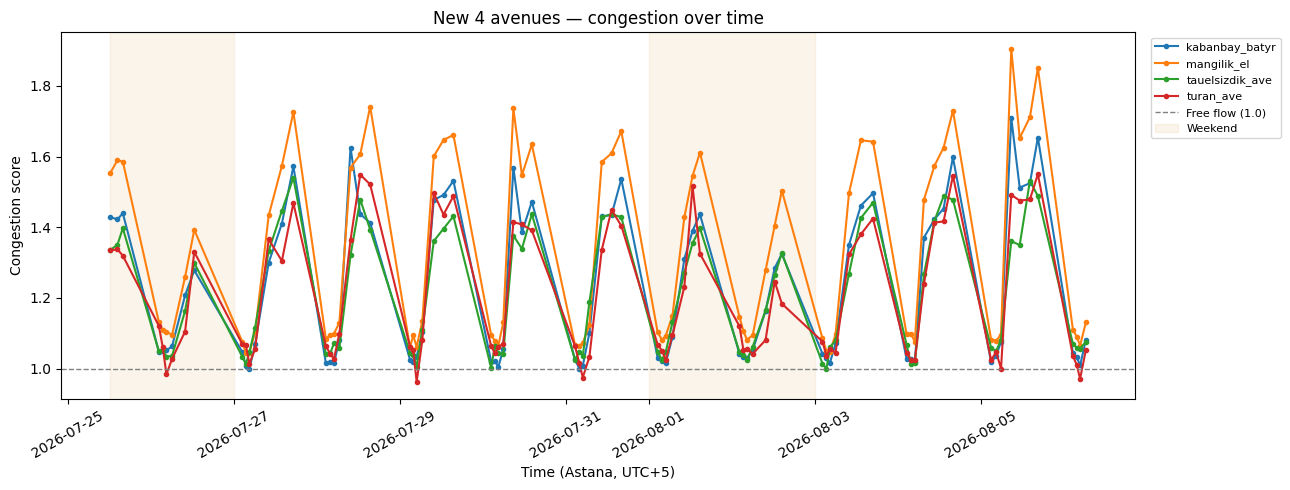

In [4]:
# One line per avenue, congestion score against real Astana-local time.
# The dashed line at 1.0 marks "as fast as this avenue has ever been."
# Weekend periods (Sat/Sun) are shaded so daily rush-hour cycling (which
# repeats every single day) doesn't get visually confused with a weekly
# weekday-vs-weekend pattern -- they are two different, separable signals.
fig, ax = plt.subplots(figsize=(13, 5))
for seg_id, group in new4.sort_values("astana_time").groupby("segment_id"):
    ax.plot(group["astana_time"], group["congestion_score"], marker="o", markersize=3, label=seg_id)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Free flow (1.0)")

# Shade weekend spans (Saturday 00:00 to Monday 00:00, Astana time)
t_min, t_max = new4["astana_time"].min(), new4["astana_time"].max()
span_start = t_min.normalize() - pd.Timedelta(days=int(t_min.dayofweek))  # back up to the preceding Monday
current = span_start
shaded_label_added = False
while current <= t_max:
    sat_start = current + pd.Timedelta(days=5)  # Saturday
    mon_start = current + pd.Timedelta(days=7)  # following Monday
    if mon_start >= t_min and sat_start <= t_max:
        ax.axvspan(max(sat_start, t_min), min(mon_start, t_max), color="#e3a857", alpha=0.12,
                   label="Weekend" if not shaded_label_added else None)
        shaded_label_added = True
    current += pd.Timedelta(days=7)

ax.set_xlabel("Time (Astana, UTC+5)"); ax.set_ylabel("Congestion score")
ax.set_title("New 4 avenues \u2014 congestion over time")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 4.2 Distributions

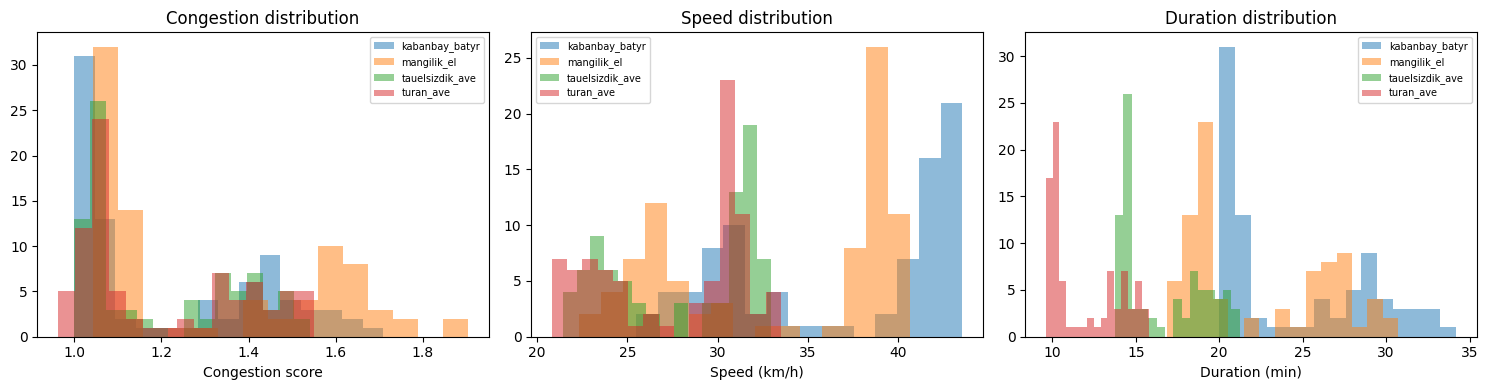

In [5]:
# Histograms show the SHAPE of each avenue's typical congestion, not just
# its average \u2014 e.g. an avenue with a wide spread is less predictable
# than one that's consistently around the same value.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for seg_id, group in new4.groupby("segment_id"):
    axes[0].hist(group["congestion_score"], bins=15, alpha=0.5, label=seg_id)
    axes[1].hist(group["avg_speed_kmh"], bins=15, alpha=0.5, label=seg_id)
    axes[2].hist(group["duration_sec"] / 60, bins=15, alpha=0.5, label=seg_id)
axes[0].set_xlabel("Congestion score"); axes[0].set_title("Congestion distribution")
axes[1].set_xlabel("Speed (km/h)"); axes[1].set_title("Speed distribution")
axes[2].set_xlabel("Duration (min)"); axes[2].set_title("Duration distribution")
for ax in axes: ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

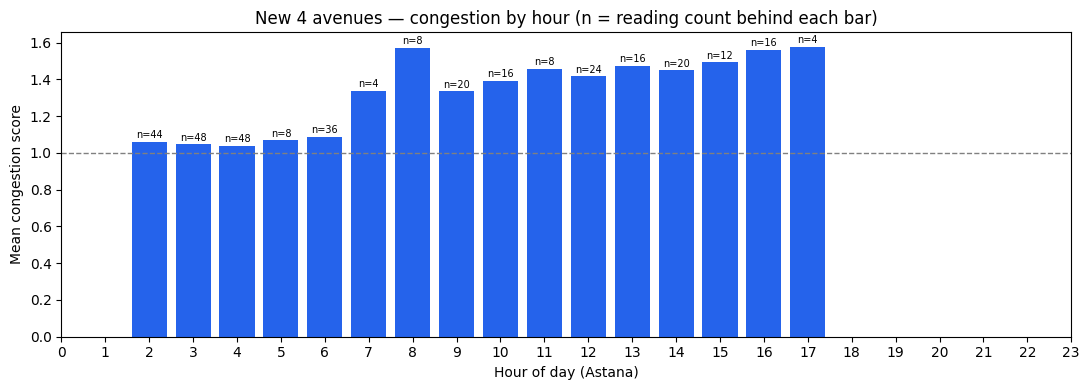

,mean_congestion,n_readings
hour_astana,,
17,1.577,4
8,1.570,8
16,1.560,16
15,1.493,12
13,1.473,16
11,1.459,8
14,1.449,20
12,1.417,24
10,1.392,16


In [6]:
# Group by hour and show BOTH the average congestion AND how many
# readings that average is based on. A high average from only 1-2
# readings is much less trustworthy than one from 10+.
hourly_new4 = new4.groupby("hour_astana").agg(
    mean_congestion=("congestion_score", "mean"),
    n_readings=("congestion_score", "count"),
).round(3)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly_new4.index, hourly_new4["mean_congestion"], color="#2563eb")
for hour, row in hourly_new4.iterrows():
    n_val = int(row["n_readings"])
    ax.text(hour, row["mean_congestion"] + 0.02, f"n={n_val}", ha="center", fontsize=7)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Hour of day (Astana)"); ax.set_ylabel("Mean congestion score")
ax.set_title("New 4 avenues \u2014 congestion by hour (n = reading count behind each bar)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()
hourly_new4.sort_values("mean_congestion", ascending=False)

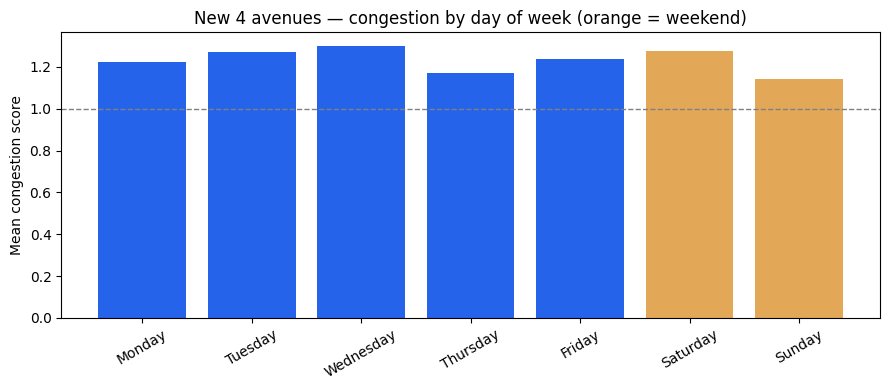

,mean_congestion,n_readings
day_name,,
Monday,1.223,56
Tuesday,1.269,56
Wednesday,1.300,56
Thursday,1.170,44
Friday,1.236,28
Saturday,1.274,40
Sunday,1.141,52


In [7]:
daily_new4 = new4.groupby("day_name").agg(
    mean_congestion=("congestion_score", "mean"),
    n_readings=("congestion_score", "count"),
).round(3)
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_new4 = daily_new4.reindex([d for d in day_order if d in daily_new4.index])

fig, ax = plt.subplots(figsize=(9, 4))
# Color weekends differently so the weekday/weekend contrast is visible at a glance
colors = ["#2563eb" if d not in ["Saturday","Sunday"] else "#e3a857" for d in daily_new4.index]
ax.bar(daily_new4.index, daily_new4["mean_congestion"], color=colors)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Mean congestion score")
ax.set_title("New 4 avenues \u2014 congestion by day of week (orange = weekend)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
daily_new4

## 5. EDA — Original avenues

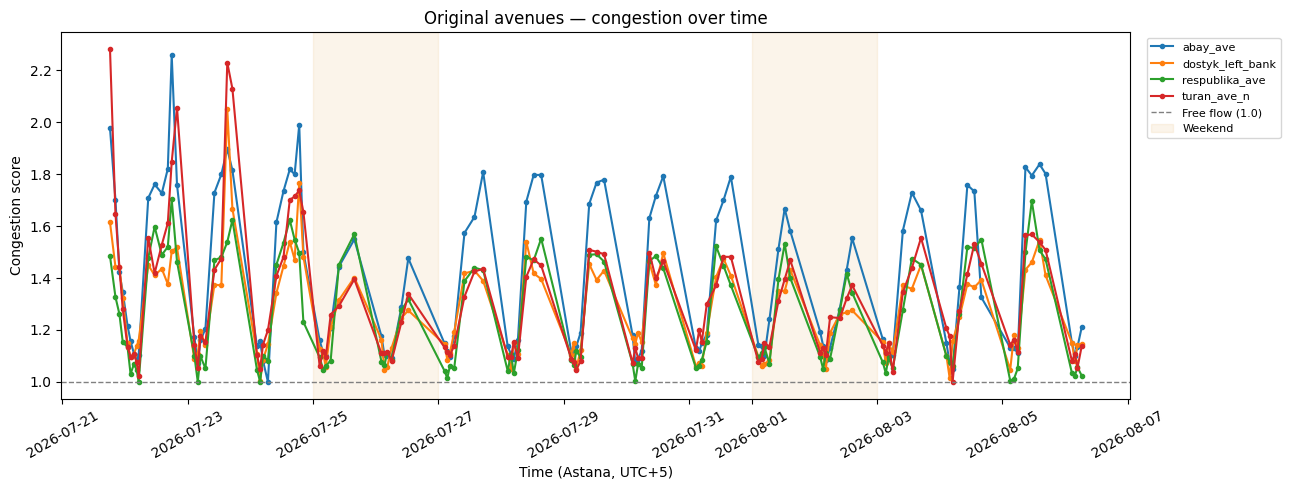

In [8]:
# One line per avenue, congestion score against real Astana-local time.
# The dashed line at 1.0 marks "as fast as this avenue has ever been."
# Weekend periods (Sat/Sun) are shaded so daily rush-hour cycling (which
# repeats every single day) doesn't get visually confused with a weekly
# weekday-vs-weekend pattern -- they are two different, separable signals.
fig, ax = plt.subplots(figsize=(13, 5))
for seg_id, group in old4.sort_values("astana_time").groupby("segment_id"):
    ax.plot(group["astana_time"], group["congestion_score"], marker="o", markersize=3, label=seg_id)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Free flow (1.0)")

# Shade weekend spans (Saturday 00:00 to Monday 00:00, Astana time)
t_min, t_max = old4["astana_time"].min(), old4["astana_time"].max()
span_start = t_min.normalize() - pd.Timedelta(days=int(t_min.dayofweek))  # back up to the preceding Monday
current = span_start
shaded_label_added = False
while current <= t_max:
    sat_start = current + pd.Timedelta(days=5)  # Saturday
    mon_start = current + pd.Timedelta(days=7)  # following Monday
    if mon_start >= t_min and sat_start <= t_max:
        ax.axvspan(max(sat_start, t_min), min(mon_start, t_max), color="#e3a857", alpha=0.12,
                   label="Weekend" if not shaded_label_added else None)
        shaded_label_added = True
    current += pd.Timedelta(days=7)

ax.set_xlabel("Time (Astana, UTC+5)"); ax.set_ylabel("Congestion score")
ax.set_title("Original avenues \u2014 congestion over time")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

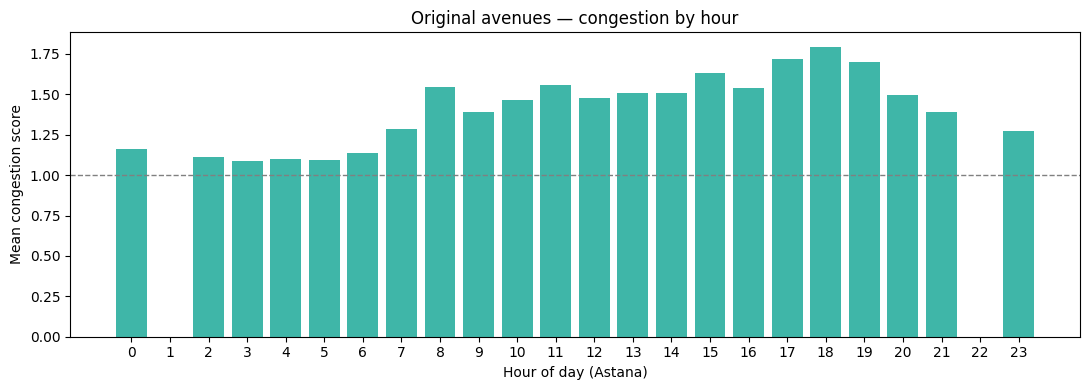

,mean_congestion,n_readings
hour_astana,,
18,1.794,8
17,1.718,12
19,1.699,4
15,1.634,20
11,1.557,12
8,1.547,12
16,1.540,24
13,1.511,16
14,1.511,20


In [9]:
hourly_old4 = old4.groupby("hour_astana").agg(
    mean_congestion=("congestion_score", "mean"),
    n_readings=("congestion_score", "count"),
).round(3)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly_old4.index, hourly_old4["mean_congestion"], color="#3fb6a8")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Hour of day (Astana)"); ax.set_ylabel("Mean congestion score")
ax.set_title("Original avenues \u2014 congestion by hour")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()
hourly_old4.sort_values("mean_congestion", ascending=False)

### 5.1 Day-of-week pattern — original avenues (this is the correct chart to check weekday vs weekend, not the raw time series above)

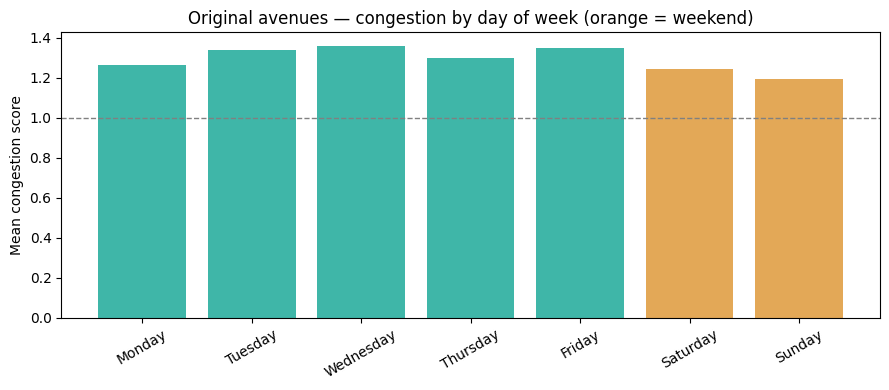

,mean_congestion,n_readings
day_name,,
Monday,1.264,56
Tuesday,1.340,72
Wednesday,1.358,100
Thursday,1.297,76
Friday,1.349,68
Saturday,1.241,52
Sunday,1.194,52


In [9]:
daily_old4 = old4.groupby("day_name").agg(
    mean_congestion=("congestion_score", "mean"),
    n_readings=("congestion_score", "count"),
).round(3)
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_old4 = daily_old4.reindex([d for d in day_order if d in daily_old4.index])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#3fb6a8" if d not in ["Saturday","Sunday"] else "#e3a857" for d in daily_old4.index]
ax.bar(daily_old4.index, daily_old4["mean_congestion"], color=colors)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Mean congestion score")
ax.set_title("Original avenues \u2014 congestion by day of week (orange = weekend)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
daily_old4

## 6. Weather

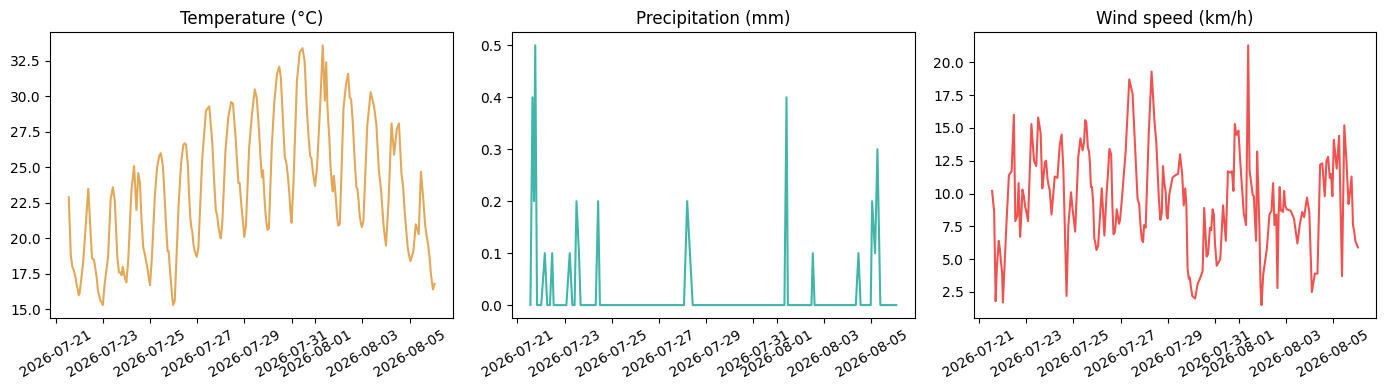

Weather range across your data:
       temperature_c  precipitation_mm  snowfall_cm  wind_speed_kmh
count         205.00            205.00        205.0          205.00
mean           22.89              0.02          0.0            9.38
std             4.47              0.07          0.0            3.59
min            15.30              0.00          0.0            1.50
25%            19.10              0.00          0.0            7.30
50%            22.60              0.00          0.0            9.10
75%            25.80              0.00          0.0           11.70
max            33.60              0.50          0.0           21.30


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(weather["timestamp_utc"], weather["temperature_c"], color="#e3a857")
axes[0].set_title("Temperature (\u00b0C)"); axes[0].tick_params(axis="x", rotation=30)
axes[1].plot(weather["timestamp_utc"], weather["precipitation_mm"], color="#3fb6a8")
axes[1].set_title("Precipitation (mm)"); axes[1].tick_params(axis="x", rotation=30)
axes[2].plot(weather["timestamp_utc"], weather["wind_speed_kmh"], color="#ef5350")
axes[2].set_title("Wind speed (km/h)"); axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("Weather range across your data:")
print(weather[["temperature_c","precipitation_mm","snowfall_cm","wind_speed_kmh"]].describe().round(2))

## 7. Feature engineering 

In [11]:
def build_features(df, weather_df):
    df = df.copy()
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_astana"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_astana"] / 24)

    # Nearest-timestamp join: match each traffic reading to the closest
    # weather reading in time (they're not collected at exactly the same
    # moment, so an exact-match join would drop almost everything).
    df = df.sort_values("timestamp_utc")
    df = pd.merge_asof(
        df,
        weather_df[["timestamp_utc","temperature_c","precipitation_mm","snowfall_cm","wind_speed_kmh"]].sort_values("timestamp_utc"),
        on="timestamp_utc", direction="nearest",
    )

    # Lag features: what was this SAME avenue's congestion the previous
    # time we checked, and how many minutes ago was that (polling isn't
    # perfectly regular, so this matters).
    df = df.sort_values(["segment_id","timestamp_utc"])
    df["prev_congestion_score"] = df.groupby("segment_id")["congestion_score"].shift(1)
    df["prev_timestamp"] = df.groupby("segment_id")["timestamp_utc"].shift(1)
    df["minutes_since_prev"] = (df["timestamp_utc"] - df["prev_timestamp"]).dt.total_seconds() / 60

    seg_dummies = pd.get_dummies(df["segment_id"], prefix="seg")
    df = pd.concat([df, seg_dummies], axis=1)

    # The very first reading per avenue has no "previous" value, so it
    # can't be used for training (drop those rows only).
    model_df = df.dropna(subset=["prev_congestion_score"]).reset_index(drop=True)
    feature_cols = [
        "prev_congestion_score","minutes_since_prev","hour_sin","hour_cos",
        "is_weekend","temperature_c","precipitation_mm","snowfall_cm","wind_speed_kmh",
    ] + list(seg_dummies.columns)
    return model_df, feature_cols

new4_model_df, new4_feature_cols = build_features(new4, weather)
old4_model_df, old4_feature_cols = build_features(old4, weather)
print(f"New 4 avenues: {len(new4_model_df)} modelable rows")
print(f"Original avenues: {len(old4_model_df)} modelable rows")
print()
print("Feature list (weather IS included):")
print(new4_feature_cols)

New 4 avenues: 328 modelable rows
Original avenues: 472 modelable rows

Feature list (weather IS included):
['prev_congestion_score', 'minutes_since_prev', 'hour_sin', 'hour_cos', 'is_weekend', 'temperature_c', 'precipitation_mm', 'snowfall_cm', 'wind_speed_kmh', 'seg_kabanbay_batyr', 'seg_mangilik_el', 'seg_tauelsizdik_ave', 'seg_turan_ave']


In [12]:
# Split the data collection period in half and compare weather variety
# between the first half and second half \u2014 if the second half has a much
# wider range, that alone can explain why the model finds it "harder" now.
weather_sorted = weather.sort_values("timestamp_utc").reset_index(drop=True)
midpoint = len(weather_sorted) // 2
first_half = weather_sorted.iloc[:midpoint]
second_half = weather_sorted.iloc[midpoint:]

comparison = pd.DataFrame({
    "first_half": [first_half["temperature_c"].std(), first_half["temperature_c"].min(),
                    first_half["temperature_c"].max(), first_half["precipitation_mm"].sum()],
    "second_half": [second_half["temperature_c"].std(), second_half["temperature_c"].min(),
                     second_half["temperature_c"].max(), second_half["precipitation_mm"].sum()],
}, index=["temp_std_dev", "temp_min", "temp_max", "total_precipitation_mm"])

print(comparison.round(2))
print()
print("A bigger temp_std_dev, wider min/max range, or more precipitation in the second")
print("half means genuinely more varied conditions \u2014 a harder, but more realistic, problem.")

                        first_half  second_half
temp_std_dev                  3.79         4.26
temp_min                     15.30        16.40
temp_max                     29.60        33.60
total_precipitation_mm        2.20         1.20

A bigger temp_std_dev, wider min/max range, or more precipitation in the second
half means genuinely more varied conditions — a harder, but more realistic, problem.


## 9. Train

In [13]:
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def chrono_split(model_df, test_frac=0.2):
    # Chronological split: train on the earlier portion, test on the most
    # recent portion. Never randomly shuffle time-series data \u2014 that
    # would let the model "peek" at the future during training.
    model_df = model_df.sort_values("timestamp_utc")
    split_idx = int(len(model_df) * (1 - test_frac))
    cutoff = model_df.iloc[split_idx]["timestamp_utc"] if split_idx < len(model_df) else model_df["timestamp_utc"].max()
    train_df = model_df[model_df["timestamp_utc"] < cutoff]
    test_df = model_df[model_df["timestamp_utc"] >= cutoff]
    return train_df, test_df


def compare_models(model_df, feature_cols, label):
    train_df, test_df = chrono_split(model_df)
    print(f"[{label}] train={len(train_df)}, test={len(test_df)}")
    if len(train_df) < 10 or len(test_df) < 3:
        print(f"[{label}] Not enough data yet for a meaningful comparison.")
        return None

    X_train, y_train = train_df[feature_cols], train_df["congestion_score"]
    X_test, y_test = test_df[feature_cols], test_df["congestion_score"]

    results = []
    # Baseline: "it'll be the same as last time we checked" \u2014 the bar
    # every real model needs to beat to be worth using.
    baseline_mae = mean_absolute_error(y_test, test_df["prev_congestion_score"])
    results.append({"model": "Persistence baseline", "test_mae": round(baseline_mae, 4)})

    candidates = {
        "Ridge (Linear)": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        "LightGBM": lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                                        min_child_samples=5, random_state=42, verbose=-1),
    }
    fitted_models = {}
    for name, clf in candidates.items():
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        results.append({"model": name, "test_mae": round(mae, 4)})
        fitted_models[name] = clf

    results_df = pd.DataFrame(results)
    results_df["vs_baseline_pct"] = round((1 - results_df["test_mae"] / baseline_mae) * 100, 1)
    results_df = results_df.sort_values("test_mae").reset_index(drop=True)
    return {"results": results_df, "fitted_models": fitted_models, "test_df": test_df, "train_df": train_df}


print("=== NEW 4 AVENUES ===")
new4_comparison = compare_models(new4_model_df, new4_feature_cols, "NEW 4 AVENUES")
print()
print("=== ORIGINAL AVENUES ===")
old4_comparison = compare_models(old4_model_df, old4_feature_cols, "ORIGINAL AVENUES")

=== NEW 4 AVENUES ===
[NEW 4 AVENUES] train=260, test=68

=== ORIGINAL AVENUES ===
[ORIGINAL AVENUES] train=376, test=96


### 9.1 Results — New 4 avenues

In [14]:
if new4_comparison is not None:
    display(new4_comparison["results"])

,model,test_mae,vs_baseline_pct
0,Ridge (Linear),0.0822,47.8
1,LightGBM,0.1096,30.4
2,Random Forest,0.1196,24.0
3,Persistence baseline,0.1574,-0.0


### 9.2 Results — Original avenues

In [15]:
if old4_comparison is not None:
    display(old4_comparison["results"])

,model,test_mae,vs_baseline_pct
0,LightGBM,0.0571,61.0
1,Random Forest,0.0641,56.3
2,Ridge (Linear),0.0849,42.1
3,Persistence baseline,0.1465,0.0


## 10. Feature importance 

Showing feature importance for: Ridge (Linear)


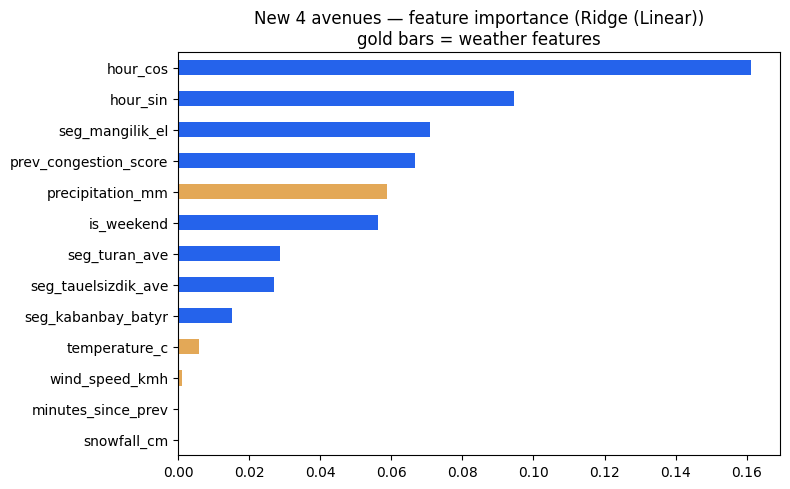

Weather features account for 11.2% of total feature importance.


In [16]:
if new4_comparison is not None:
    results = new4_comparison["results"]
    importable = results[results["model"].isin(["Ridge (Linear)", "Random Forest", "LightGBM"])]
    best_name = importable.iloc[0]["model"]
    best_model = new4_comparison["fitted_models"][best_name]
    print(f"Showing feature importance for: {best_name}")

    if hasattr(best_model, "feature_importances_"):
        importances = pd.Series(best_model.feature_importances_, index=new4_feature_cols).sort_values()
    else:
        importances = pd.Series(np.abs(best_model.coef_), index=new4_feature_cols).sort_values()

    weather_features = {"temperature_c", "precipitation_mm", "snowfall_cm", "wind_speed_kmh"}
    colors = ["#e3a857" if f in weather_features else "#2563eb" for f in importances.index]

    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(f"New 4 avenues \u2014 feature importance ({best_name})\ngold bars = weather features")
    plt.tight_layout()
    plt.show()

    weather_share = importances[importances.index.isin(weather_features)].sum() / importances.sum() * 100
    print(f"Weather features account for {weather_share:.1f}% of total feature importance.")

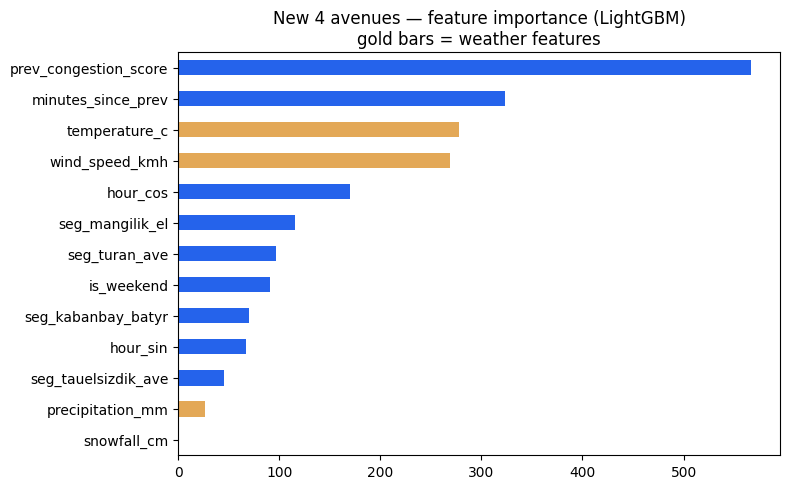

Weather features account for 27.1% of total LightGBM feature importance.


In [18]:
# Explicitly uses LightGBM regardless of which model won the comparison
# in section 9 (Ridge won last time) -- useful to see LightGBM's own
# feature importance on its own terms, since tree-based importance and
# linear coefficients aren't directly comparable anyway.

if new4_comparison is not None:
    new4_lgbm_model = new4_comparison["fitted_models"]["LightGBM"]

    importances = pd.Series(new4_lgbm_model.feature_importances_, index=new4_feature_cols).sort_values()

    weather_features = {"temperature_c", "precipitation_mm", "snowfall_cm", "wind_speed_kmh"}
    colors = ["#e3a857" if f in weather_features else "#2563eb" for f in importances.index]

    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax, color=colors)
    ax.set_title("New 4 avenues \u2014 feature importance (LightGBM)\ngold bars = weather features")
    plt.tight_layout()
    plt.show()

    weather_share = importances[importances.index.isin(weather_features)].sum() / importances.sum() * 100
    print(f"Weather features account for {weather_share:.1f}% of total LightGBM feature importance.")

Showing feature importance for: LightGBM


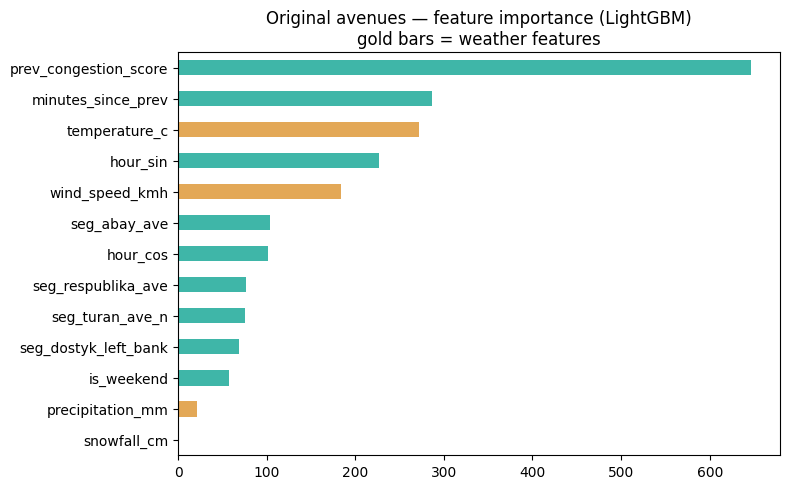

Weather features account for 22.5% of total feature importance.


In [17]:
if old4_comparison is not None:
    old4_results = old4_comparison["results"]
    old4_importable = old4_results[old4_results["model"].isin(["Ridge (Linear)", "Random Forest", "LightGBM"])]
    old4_best_name = old4_importable.iloc[0]["model"]
    old4_best_model = old4_comparison["fitted_models"][old4_best_name]
    print(f"Showing feature importance for: {old4_best_name}")

    if hasattr(old4_best_model, "feature_importances_"):
        old4_importances = pd.Series(old4_best_model.feature_importances_, index=old4_feature_cols).sort_values()
    else:
        old4_importances = pd.Series(np.abs(old4_best_model.coef_), index=old4_feature_cols).sort_values()

    weather_features = {"temperature_c", "precipitation_mm", "snowfall_cm", "wind_speed_kmh"}
    old4_colors = ["#e3a857" if f in weather_features else "#3fb6a8" for f in old4_importances.index]

    fig, ax = plt.subplots(figsize=(8, 5))
    old4_importances.plot(kind="barh", ax=ax, color=old4_colors)
    ax.set_title(f"Original avenues \u2014 feature importance ({old4_best_name})\ngold bars = weather features")
    plt.tight_layout()
    plt.show()

    old4_weather_share = old4_importances[old4_importances.index.isin(weather_features)].sum() / old4_importances.sum() * 100
    print(f"Weather features account for {old4_weather_share:.1f}% of total feature importance.")

## 11. Predicted vs actual

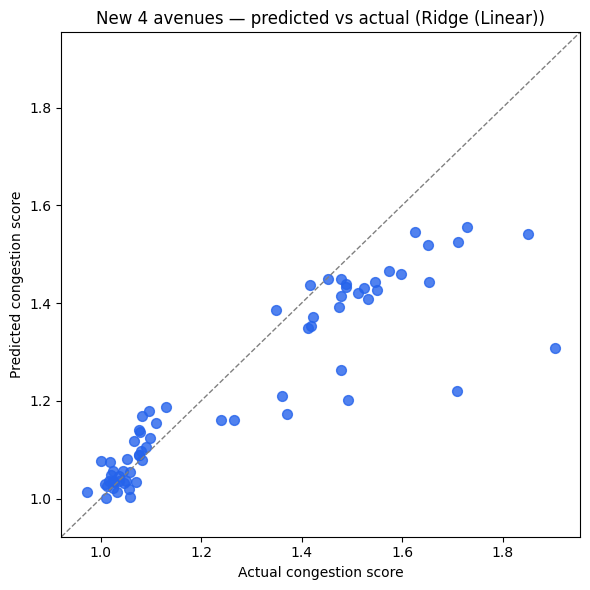

In [18]:
if new4_comparison is not None:
    test_df = new4_comparison["test_df"]
    X_test = test_df[new4_feature_cols]
    preds = best_model.predict(X_test)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(test_df["congestion_score"], preds, alpha=0.8, s=50, color="#2563eb")
    lims = [min(test_df["congestion_score"].min(), preds.min()) - 0.05,
            max(test_df["congestion_score"].max(), preds.max()) + 0.05]
    ax.plot(lims, lims, "--", color="gray", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual congestion score"); ax.set_ylabel("Predicted congestion score")
    ax.set_title(f"New 4 avenues \u2014 predicted vs actual ({best_name})")
    plt.tight_layout()
    plt.show()

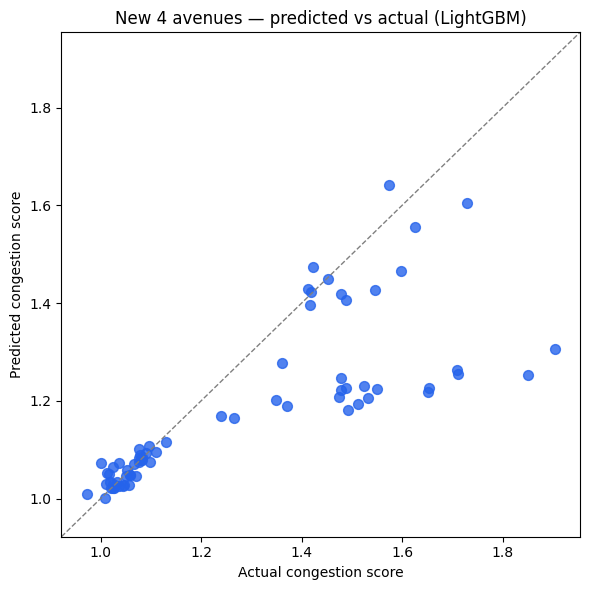

In [19]:
# Explicitly uses LightGBM regardless of which model won the comparison
# in section 9 -- same predicted-vs-actual view, just for LightGBM
# specifically rather than whichever model happened to win.

if new4_comparison is not None:
    new4_lgbm_model = new4_comparison["fitted_models"]["LightGBM"]
    test_df = new4_comparison["test_df"]
    X_test = test_df[new4_feature_cols]
    preds = new4_lgbm_model.predict(X_test)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(test_df["congestion_score"], preds, alpha=0.8, s=50, color="#2563eb")
    lims = [min(test_df["congestion_score"].min(), preds.min()) - 0.05,
            max(test_df["congestion_score"].max(), preds.max()) + 0.05]
    ax.plot(lims, lims, "--", color="gray", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual congestion score"); ax.set_ylabel("Predicted congestion score")
    ax.set_title("New 4 avenues \u2014 predicted vs actual (LightGBM)")
    plt.tight_layout()
    plt.show()

## 12. Live prediction demo

In [19]:
def predict_next(model, feature_cols, segment_df, weather_df, segment_ids):
    # Build a "what happens next" feature row from each avenue's most
    # recent known reading, exactly like a real prediction button would.
    latest_weather = weather_df.sort_values("timestamp_utc").iloc[-1]
    now = pd.Timestamp.now("UTC").tz_localize(None)
    hour_astana = (now + pd.Timedelta(hours=5)).hour
    day_of_week = now.dayofweek

    rows = []
    for seg_id in segment_ids:
        seg_history = segment_df[segment_df["segment_id"] == seg_id].sort_values("timestamp_utc")
        if len(seg_history) == 0:
            continue
        last = seg_history.iloc[-1]
        last_ts = last["timestamp_utc"]
        last_ts = last_ts.tz_localize(None) if last_ts.tzinfo is not None else last_ts
        minutes_since = (now - last_ts).total_seconds() / 60

        row = {
            "prev_congestion_score": last["congestion_score"],
            "minutes_since_prev": max(minutes_since, 0),
            "hour_sin": np.sin(2 * np.pi * hour_astana / 24),
            "hour_cos": np.cos(2 * np.pi * hour_astana / 24),
            "is_weekend": int(day_of_week >= 5),
            "temperature_c": latest_weather["temperature_c"],
            "precipitation_mm": latest_weather["precipitation_mm"],
            "snowfall_cm": latest_weather["snowfall_cm"],
            "wind_speed_kmh": latest_weather["wind_speed_kmh"],
        }
        for col in feature_cols:
            if col.startswith("seg_"):
                row[col] = 1 if col == f"seg_{seg_id}" else 0
        rows.append((seg_id, row))

    X_pred = pd.DataFrame([r for _, r in rows])[feature_cols]
    preds = model.predict(X_pred)
    return pd.DataFrame({"segment_id": [s for s, _ in rows], "predicted_congestion_score": preds})


if new4_comparison is not None:
    prediction = predict_next(best_model, new4_feature_cols, new4, weather, NEW_4_IDS)
    print(f"Predictions using: {best_name}")
    display(prediction)

Predictions using: Ridge (Linear)


,segment_id,predicted_congestion_score
0,kabanbay_batyr,1.244441
1,turan_ave,1.229124
2,mangilik_el,1.333724
3,tauelsizdik_ave,1.232279


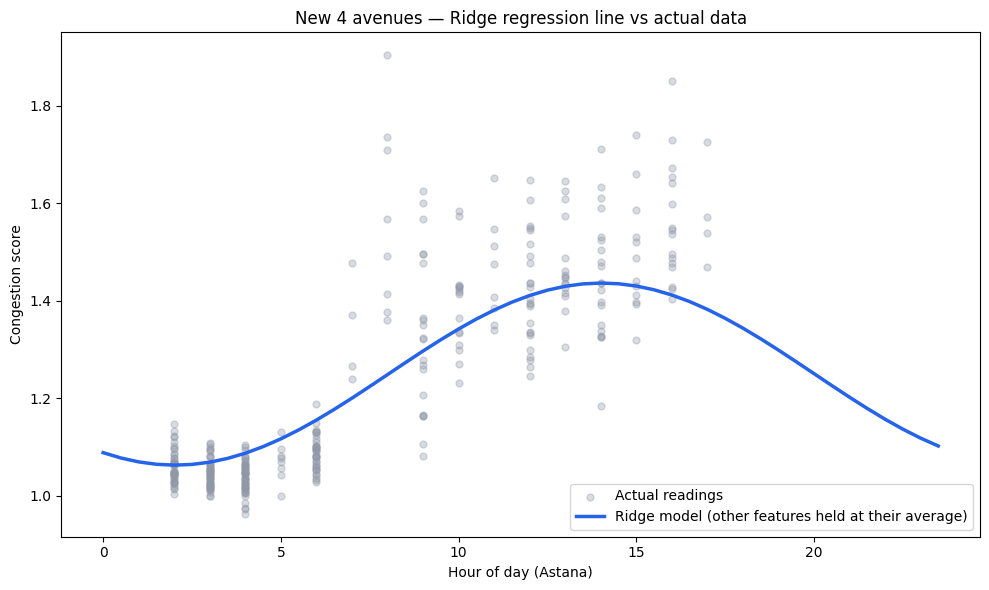

In [20]:
# Ridge is a multivariate model, so we can't plot ONE line through all its
# features at once -- instead this shows how the model responds to the
# feature that turned out to matter most (hour of day, via hour_sin/cos),
# with every other feature held at its average value. This is a standard
# technique (a "partial dependence" slice), not the full model, but it's
# an honest way to see the fitted relationship on top of real data.

if new4_comparison is not None:
    ridge_model = new4_comparison["fitted_models"]["Ridge (Linear)"]
    train_df = new4_comparison["train_df"]

    # What we hold constant: the average of every other feature in training data
    hold_constant = train_df[new4_feature_cols].mean()

    # Sweep hour-of-day from 0 to 24, recomputing hour_sin/cos each step,
    # keeping everything else fixed at its average
    hours = np.arange(0, 24, 0.5)
    sweep_rows = []
    for h in hours:
        row = hold_constant.copy()
        row["hour_sin"] = np.sin(2 * np.pi * h / 24)
        row["hour_cos"] = np.cos(2 * np.pi * h / 24)
        sweep_rows.append(row)
    sweep_df = pd.DataFrame(sweep_rows)[new4_feature_cols]
    sweep_preds = ridge_model.predict(sweep_df)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(new4["hour_astana"], new4["congestion_score"], alpha=0.35, s=25, color="#9098a8", label="Actual readings")
    ax.plot(hours, sweep_preds, color="#2563eb", linewidth=2.5, label="Ridge model (other features held at their average)")
    ax.set_xlabel("Hour of day (Astana)")
    ax.set_ylabel("Congestion score")
    ax.set_title("New 4 avenues — Ridge regression line vs actual data")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [20]:
from sklearn.metrics import mean_squared_error

def evaluate_with_bias(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    bias = (y_pred - y_true).mean()  # signed, not absolute
    print(f"[{label}] MAE={mae:.4f}  RMSE={rmse:.4f}  Mean bias={bias:+.4f}")
    return {"mae": mae, "rmse": rmse, "bias": bias}


if new4_comparison is not None:
    test_df = new4_comparison["test_df"]
    y_true = test_df["congestion_score"]
    y_pred = best_model.predict(test_df[new4_feature_cols])

    print("=== Overall ===")
    evaluate_with_bias(y_true, y_pred, "All test rows")

    print()
    print("=== Split by actual congestion level ===")
    median_congestion = y_true.median()
    low_mask = y_true <= median_congestion
    high_mask = ~low_mask
    low_stats = evaluate_with_bias(y_true[low_mask], y_pred[low_mask], f"Lower congestion (<= {median_congestion:.2f})")
    high_stats = evaluate_with_bias(y_true[high_mask], y_pred[high_mask], f"Higher congestion (> {median_congestion:.2f})")

    print()
    if abs(high_stats["bias"]) > abs(low_stats["bias"]):
        print("Bias is larger at HIGHER congestion -- the model over/under-predicts more for busier conditions.")
    else:
        print("Bias is larger at LOWER congestion in this dataset -- worth re-checking this split as more data arrives,")
        print("since it can shift as the test set composition changes.")


=== Overall ===
[All test rows] MAE=0.0822  RMSE=0.1329  Mean bias=-0.0547

=== Split by actual congestion level ===
[Lower congestion (<= 1.10)] MAE=0.0288  RMSE=0.0373  Mean bias=+0.0170
[Higher congestion (> 1.10)] MAE=0.1356  RMSE=0.1842  Mean bias=-0.1264

Bias is larger at HIGHER congestion -- the model over/under-predicts more for busier conditions.


In [28]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

if new4_comparison is not None:
    train_df = new4_comparison["train_df"]
    X_train = train_df[new4_feature_cols]
    y_train = train_df["congestion_score"]

    # Chronological folds only — same as the LightGBM search
    tscv = TimeSeriesSplit(n_splits=3)

    # Ridge really only has ONE meaningful hyperparameter (alpha), so an
    # exhaustive grid search is more appropriate here than a random one
    ridge_param_grid = {
        "alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    }

    ridge_search = GridSearchCV(
        Ridge(),
        param_grid=ridge_param_grid,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
    )
    ridge_search.fit(X_train, y_train)

    print("Best alpha found:", ridge_search.best_params_["alpha"])
    print(f"Best cross-validated MAE during search: {-ridge_search.best_score_:.4f}")

Best alpha found: 0.001
Best cross-validated MAE during search: 0.0807


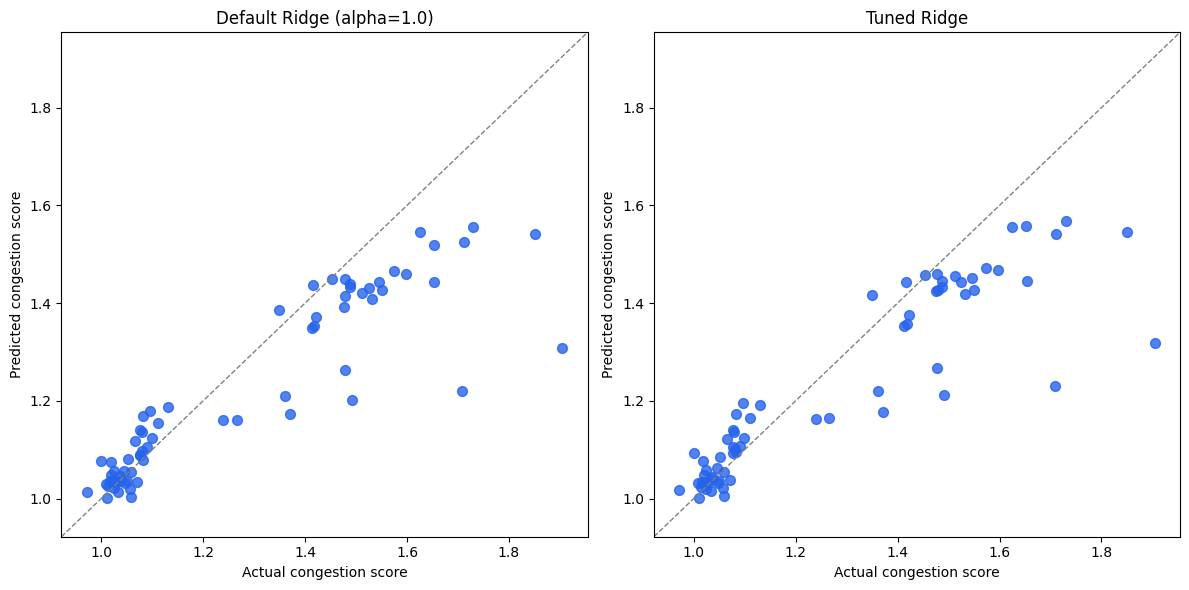

Compare the two scatter plots — if the tuned model's points sit closer to the
diagonal, tuning improved the fit.


In [29]:
if new4_comparison is not None:
    tuned_ridge_model = ridge_search.best_estimator_
    default_ridge_model = new4_comparison["fitted_models"]["Ridge (Linear)"]
    test_df = new4_comparison["test_df"]
    y_true = test_df["congestion_score"]

    default_preds = default_ridge_model.predict(test_df[new4_feature_cols])
    tuned_preds = tuned_ridge_model.predict(test_df[new4_feature_cols])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, preds, title in [(axes[0], default_preds, "Default Ridge (alpha=1.0)"), (axes[1], tuned_preds, "Tuned Ridge")]:
        ax.scatter(y_true, preds, alpha=0.8, s=50, color="#2563eb")
        lims = [min(y_true.min(), preds.min()) - 0.05, max(y_true.max(), preds.max()) + 0.05]
        ax.plot(lims, lims, "--", color="gray", linewidth=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Actual congestion score"); ax.set_ylabel("Predicted congestion score")
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

    print("Compare the two scatter plots — if the tuned model's points sit closer to the")
    print("diagonal, tuning improved the fit.")

## 14. Hyperparameter tuning LightGBM

In [24]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

if new4_comparison is not None:
    train_df = new4_comparison["train_df"]
    X_train = train_df[new4_feature_cols]
    y_train = train_df["congestion_score"]

    # Chronological folds only \u2014 each validation fold comes after its
    # training fold in time, never before.
    tscv = TimeSeriesSplit(n_splits=3)

    param_distributions = {
        "n_estimators": [50, 100, 150, 200, 300],
        "max_depth": [3, 4, 5, 6, -1],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
        "num_leaves": [7, 15, 31],
        "min_child_samples": [3, 5, 8, 10, 15],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.1, 0.5, 1.0],
        "reg_lambda": [0, 0.1, 0.5, 1.0],
    }

    base_model = lgb.LGBMRegressor(random_state=42, verbose=-1)

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_distributions,
        n_iter=50,                 # 50 random combinations, not exhaustive
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)

    print("Best parameters found:")
    print(search.best_params_)
    print(f"Best cross-validated MAE during search: {-search.best_score_:.4f}")

Best parameters found:
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best cross-validated MAE during search: 0.0598


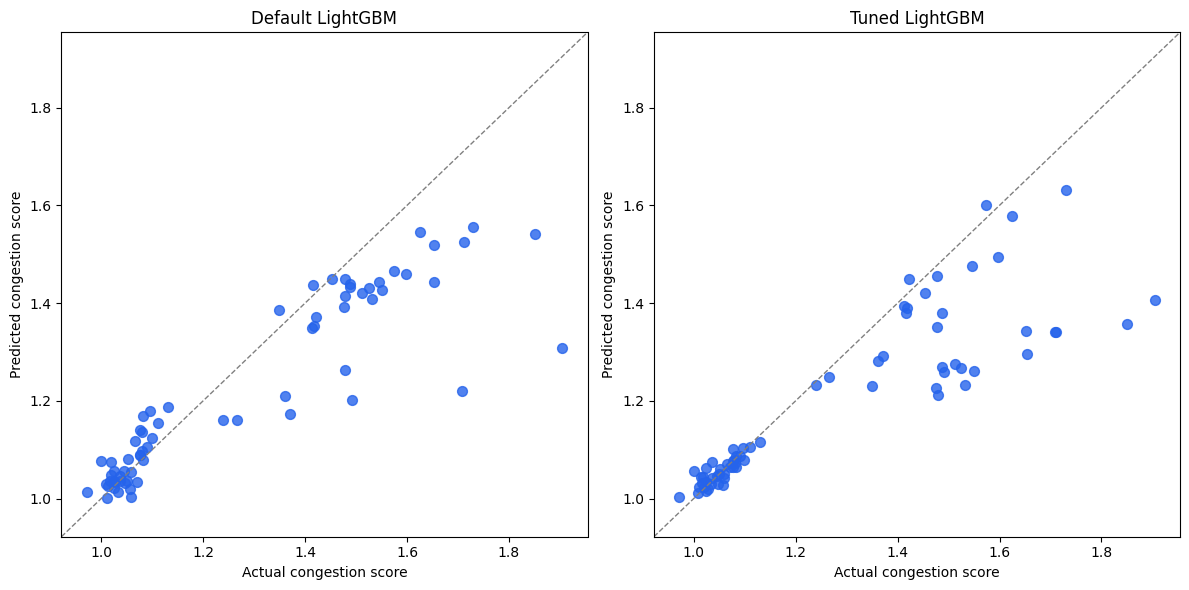

Compare the two scatter plots — if the tuned model's points sit closer to the
diagonal at the high end (right side), tuning improved the over-prediction bias.


In [26]:
if new4_comparison is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, preds, title in [(axes[0], default_preds, "Default LightGBM"), (axes[1], tuned_preds, "Tuned LightGBM")]:
        ax.scatter(y_true, preds, alpha=0.8, s=50, color="#2563eb")
        lims = [min(y_true.min(), preds.min()) - 0.05, max(y_true.max(), preds.max()) + 0.05]
        ax.plot(lims, lims, "--", color="gray", linewidth=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Actual congestion score"); ax.set_ylabel("Predicted congestion score")
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print("Compare the two scatter plots \u2014 if the tuned model's points sit closer to the")
    print("diagonal at the high end (right side), tuning improved the over-prediction bias.")

In [30]:
# Compares TUNED LightGBM (from section 14's search) against TUNED Ridge
# (from section 18's ridge_search) on the same held-out test set, in the
# same results-table format used throughout the notebook. Needs section 14
# and section 18 to have already run in this session (uses their `search`
# and `ridge_search` objects directly, not retraining).

if new4_comparison is not None:
    test_df = new4_comparison["test_df"]
    y_true = test_df["congestion_score"]

    baseline_mae = mean_absolute_error(y_true, test_df["prev_congestion_score"])

    tuned_lgbm_model = search.best_estimator_
    tuned_ridge_model = ridge_search.best_estimator_

    tuned_lgbm_preds = tuned_lgbm_model.predict(test_df[new4_feature_cols])
    tuned_ridge_preds = tuned_ridge_model.predict(test_df[new4_feature_cols])

    tuned_results = pd.DataFrame([
        {"model": "Persistence baseline", "test_mae": round(baseline_mae, 4)},
        {"model": "Tuned LightGBM", "test_mae": round(mean_absolute_error(y_true, tuned_lgbm_preds), 4)},
        {"model": "Tuned Ridge", "test_mae": round(mean_absolute_error(y_true, tuned_ridge_preds), 4)},
    ])
    tuned_results["vs_baseline_pct"] = round((1 - tuned_results["test_mae"] / baseline_mae) * 100, 1)
    tuned_results = tuned_results.sort_values("test_mae").reset_index(drop=True)

    display(tuned_results)

,model,test_mae,vs_baseline_pct
0,Tuned Ridge,0.0798,49.3
1,Tuned LightGBM,0.0882,44.0
2,Persistence baseline,0.1574,-0.0


## 15. Tuning the Original avenues

In [32]:
if old4_comparison is not None:
    old4_train_df = old4_comparison["train_df"]
    old4_X_train = old4_train_df[old4_feature_cols]
    old4_y_train = old4_train_df["congestion_score"]

    old4_tscv = TimeSeriesSplit(n_splits=3)
    old4_search = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        param_distributions=param_distributions,  # same search space as section 14
        n_iter=50,
        scoring="neg_mean_absolute_error",
        cv=old4_tscv,
        random_state=42,
        n_jobs=-1,
    )
    old4_search.fit(old4_X_train, old4_y_train)

    print("Best parameters (Original avenues):")
    print(old4_search.best_params_)
    print(f"Best cross-validated MAE during search: {-old4_search.best_score_:.4f}")

Best parameters (Original avenues):
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 7, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best cross-validated MAE during search: 0.0848


Original avenues -- Default LightGBM  MAE = 0.0571
Original avenues -- Tuned LightGBM    MAE = 0.0642


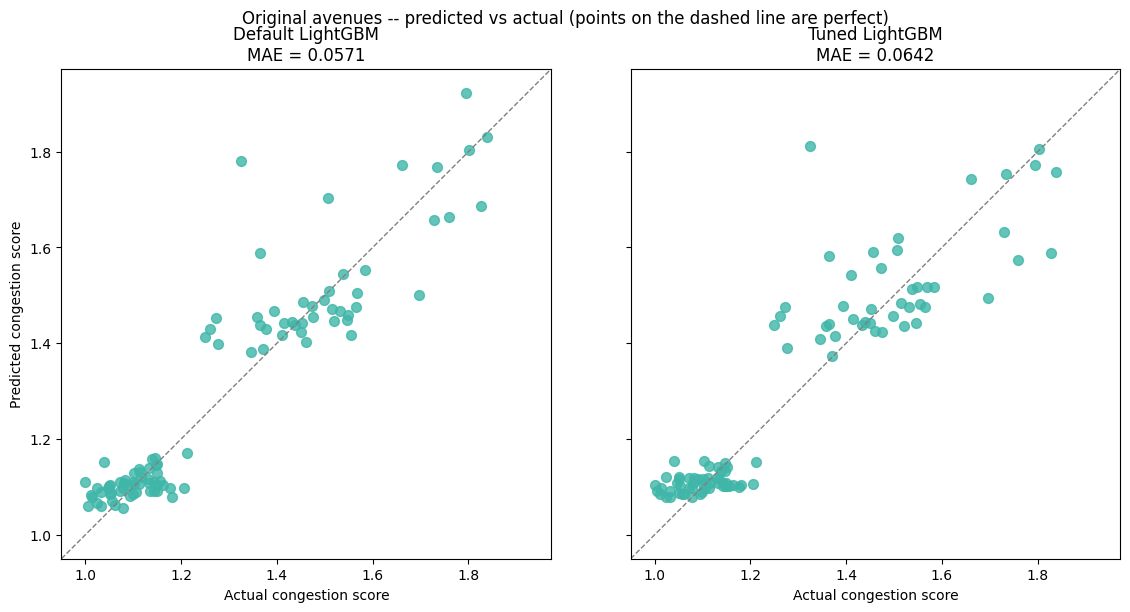


Tuning worsened test MAE by 0.0071.
Note the search was scored on training folds, so a search CV score
below the default's test MAE is not evidence that tuning helped --
this held-out comparison is.


In [42]:
# --- Section 15.1: does tuning help the Original avenues? --------------------
# Mirrors section 14.1, but for old4. Nothing is retrained here: the default
# LightGBM comes from section 9's comparison and the tuned one from section 15's
# `old4_search`, so both are scored on exactly the same held-out rows.
#
# Kept in its own variables (old4_test_df, old4_y_true) rather than reusing the
# bare `test_df` name, which elsewhere in the notebook refers to the New 4 split.

if old4_comparison is not None:
    old4_test_df = old4_comparison["test_df"]
    old4_y_true = old4_test_df["congestion_score"]
    old4_X_test = old4_test_df[old4_feature_cols]

    old4_preds = {
        "Default LightGBM": old4_comparison["fitted_models"]["LightGBM"].predict(old4_X_test),
        "Tuned LightGBM": old4_search.best_estimator_.predict(old4_X_test),
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    spread = np.concatenate([old4_y_true.to_numpy()] + list(old4_preds.values()))
    lims = [spread.min() - 0.05, spread.max() + 0.05]

    for ax, (name, preds) in zip(axes, old4_preds.items()):
        mae = mean_absolute_error(old4_y_true, preds)
        ax.scatter(old4_y_true, preds, alpha=0.8, s=50, color="#3fb6a8")
        ax.plot(lims, lims, "--", color="gray", linewidth=1)
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
        ax.set_xlabel("Actual congestion score")
        ax.set_title(f"{name}\nMAE = {mae:.4f}")
        print(f"Original avenues -- {name:17s} MAE = {mae:.4f}")

    axes[0].set_ylabel("Predicted congestion score")
    fig.suptitle("Original avenues -- predicted vs actual (points on the dashed line are perfect)")
    plt.tight_layout()
    plt.show()

    gain = (mean_absolute_error(old4_y_true, old4_preds["Default LightGBM"])
            - mean_absolute_error(old4_y_true, old4_preds["Tuned LightGBM"]))
    verdict = "improved" if gain > 0 else "worsened"
    print(f"\nTuning {verdict} test MAE by {abs(gain):.4f}.")
    print("Note the search was scored on training folds, so a search CV score")
    print("below the default's test MAE is not evidence that tuning helped --")
    print("this held-out comparison is.")

In [43]:
# --- Same table format as sections 9.2 and 14.1 ------------------------------
# Scores both LightGBM variants against the persistence baseline the rest of
# the notebook is measured on, so the Original avenues can be read next to the
# New 4 results without mentally converting between formats.

if old4_comparison is not None:
    old4_baseline_mae = mean_absolute_error(old4_y_true, old4_test_df["prev_congestion_score"])

    old4_tuned_results = pd.DataFrame(
        [{"model": "Persistence baseline", "test_mae": round(old4_baseline_mae, 4)}]
        + [{"model": name, "test_mae": round(mean_absolute_error(old4_y_true, preds), 4)}
           for name, preds in old4_preds.items()]
    )
    old4_tuned_results["vs_baseline_pct"] = round(
        (1 - old4_tuned_results["test_mae"] / old4_baseline_mae) * 100, 1
    )
    old4_tuned_results = old4_tuned_results.sort_values("test_mae").reset_index(drop=True)
    display(old4_tuned_results)

,model,test_mae,vs_baseline_pct
0,Default LightGBM,0.0571,61.0
1,Tuned LightGBM,0.0642,56.2
2,Persistence baseline,0.1465,0.0


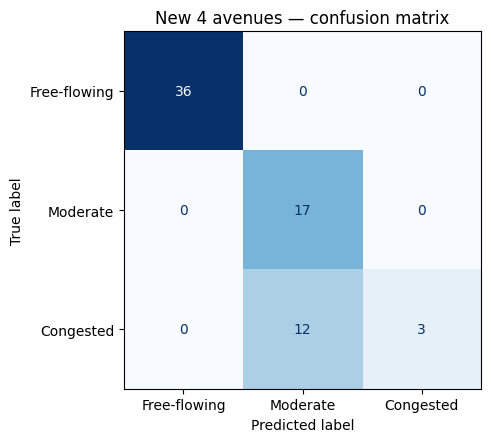

=== New 4 avenues: precision / recall / F1 / accuracy per category ===
              precision    recall  f1-score   support

Free-flowing       1.00      1.00      1.00        36
    Moderate       0.59      1.00      0.74        17
   Congested       1.00      0.20      0.33        15

    accuracy                           0.82        68
   macro avg       0.86      0.73      0.69        68
weighted avg       0.90      0.82      0.79        68



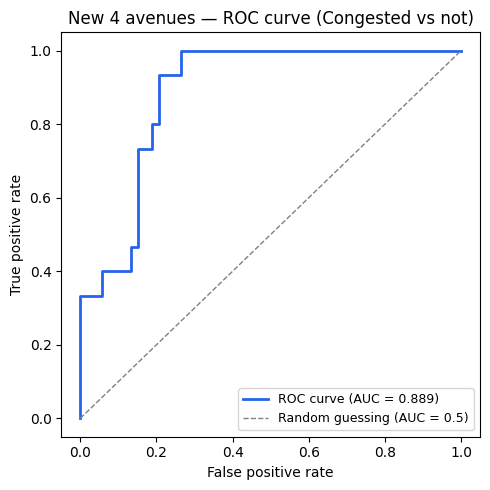

ROC-AUC: 0.889 (1.0 = perfect ranking, 0.5 = random guessing)


In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve

# Same category boundaries used by the map's color scale, so "Congested"
# here means the same thing it does everywhere else in this project.
def congestion_category(score):
    if score < 1.15:
        return "Free-flowing"
    elif score < 1.5:
        return "Moderate"
    else:
        return "Congested"

CATEGORY_ORDER = ["Free-flowing", "Moderate", "Congested"]


def show_classification_view(comparison, feature_cols, tuned_model, label, color):
    test_df = comparison["test_df"]
    y_true_score = test_df["congestion_score"]
    y_pred_score = tuned_model.predict(test_df[feature_cols])

    y_true_cat = y_true_score.apply(congestion_category)
    y_pred_cat = pd.Series(y_pred_score, index=test_df.index).apply(congestion_category)

    # Confusion matrix: rows = actual category, columns = predicted category.
    # A perfect model would have every count on the diagonal.
    cm = confusion_matrix(y_true_cat, y_pred_cat, labels=CATEGORY_ORDER)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORY_ORDER)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{label} \u2014 confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"=== {label}: precision / recall / F1 / accuracy per category ===")
    print(classification_report(y_true_cat, y_pred_cat, labels=CATEGORY_ORDER, zero_division=0))

    # ROC-AUC needs a binary target and a continuous score to rank by.
    # Framed here as "was it Congested or not" -- the operationally most
    # relevant single threshold -- using the model's own continuous
    # prediction as the ranking score (no separate classifier needed).
    y_true_binary = (y_true_score >= 1.5).astype(int)
    if y_true_binary.nunique() < 2:
        print("Only one class present in this test set for the Congested/Not split -- ROC-AUC needs both.")
        return
    auc = roc_auc_score(y_true_binary, y_pred_score)
    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_score)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random guessing (AUC = 0.5)")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"{label} \u2014 ROC curve (Congested vs not)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"ROC-AUC: {auc:.3f} (1.0 = perfect ranking, 0.5 = random guessing)")


if new4_comparison is not None:
    show_classification_view(new4_comparison, new4_feature_cols, new4_tuned_model, "New 4 avenues", "#2563eb")

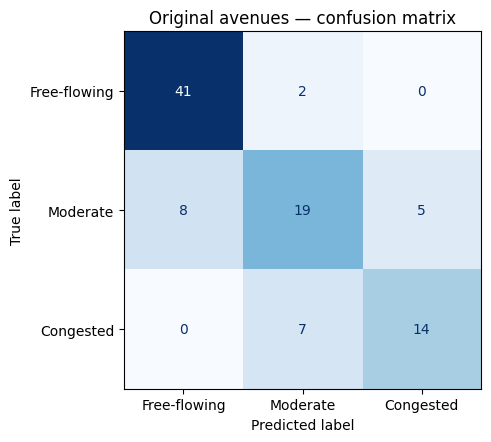

=== Original avenues: precision / recall / F1 / accuracy per category ===
              precision    recall  f1-score   support

Free-flowing       0.84      0.95      0.89        43
    Moderate       0.68      0.59      0.63        32
   Congested       0.74      0.67      0.70        21

    accuracy                           0.77        96
   macro avg       0.75      0.74      0.74        96
weighted avg       0.76      0.77      0.76        96



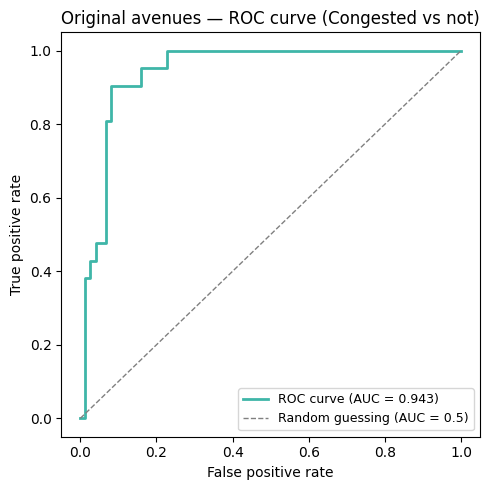

ROC-AUC: 0.943 (1.0 = perfect ranking, 0.5 = random guessing)


In [36]:
if old4_comparison is not None:
    show_classification_view(old4_comparison, old4_feature_cols, old4_tuned_model, "Original avenues", "#3fb6a8")